In [21]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# --- CONFIGURATION ---
DATA_DIR = "../data/mask_tensors"
TABULAR_PATH = "../data/processed/final_dataset.csv"
MODEL_SAVE_PATH = "../models/best_resnet.pth"
BATCH_SIZE = 256
LEARNING_RATE = 0.001
EPOCHS = 20

# --- HARDWARE ACCELERATION (Mac M4) ---
# Critical for performance on your MacBook
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print(f"✅ Using Apple MPS (M4 Pro Neural Engine)")
    print(f"   PyTorch Version: {torch.__version__}")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("✅ Using NVIDIA CUDA")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ Using CPU (Slower)")

# Check for XGBoost
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost library not found. Skipping baseline.")

✅ Using Apple MPS (M4 Pro Neural Engine)
   PyTorch Version: 2.8.0


In [22]:
# --- BASELINE: XGBoost on Tabular Data ---
xgb_acc, xgb_auc = 0.5, 0.5 # Defaults

if os.path.exists(TABULAR_PATH) and XGB_AVAILABLE:
    print("🤖 Running Tabular Baseline (XGBoost)...")
    
    # Load
    df = pd.read_csv(TABULAR_PATH)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df = df.dropna()
    
    # Feature Selection (Exclude ID/Lat/Lon/Filename)
    feature_cols = [c for c in df.columns if c not in ['id', 'target', 'lat', 'lon', 'filename']]
    X_tab = df[feature_cols].values
    y_tab = df['target'].values
    
    # Split
    X_tab_train, X_tab_test, y_tab_train, y_tab_test = train_test_split(
        X_tab, y_tab, test_size=0.2, random_state=42, stratify=y_tab
    )
    
    # Train
    xgb = XGBClassifier(n_estimators=100, learning_rate=0.05, eval_metric='logloss')
    xgb.fit(X_tab_train, y_tab_train)
    
    # Score
    y_tab_pred = xgb.predict(X_tab_test)
    y_tab_prob = xgb.predict_proba(X_tab_test)[:, 1]
    
    xgb_acc = accuracy_score(y_tab_test, y_tab_pred)
    xgb_auc = roc_auc_score(y_tab_test, y_tab_prob)
    
    print("-" * 30)
    print(f"📊 TABULAR BASELINE (XGBoost):")
    print(f"Accuracy: {xgb_acc:.4f}")
    print(f"AUC:      {xgb_auc:.4f}")
    print("-" * 30)
else:
    print("⚠️ Tabular dataset not found or XGBoost missing. Skipping baseline.")

🤖 Running Tabular Baseline (XGBoost)...
------------------------------
📊 TABULAR BASELINE (XGBoost):
Accuracy: 0.6433
AUC:      0.6958
------------------------------


In [23]:
class SemanticStackDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.files = file_list
        self.transform = transform
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        path = self.files[idx]
        filename = os.path.basename(path)
        
        # Extract Target from filename (Format: ID_TARGET.npy)
        try:
            target_str = filename.split('_')[-1].split('.')[0]
            target = int(target_str)
        except:
            target = 0 # Fallback
            
        # Load Tensor (H, W, C)
        img_array = np.load(path)
        
        # Normalize to 0-1 float
        img_array = img_array.astype(np.float32) / 255.0
        
        # Permute to (C, H, W) for PyTorch
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)
        
        # Apply Augmentations
        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        return img_tensor, torch.tensor(target, dtype=torch.float32).unsqueeze(0)

In [24]:
# --- PREPARE DATA ---
if not os.path.exists(DATA_DIR):
    print(f"⚠️ Warning: Folder {DATA_DIR} not found.")
    all_files = []
else:
    all_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.npy')]
    print(f"Found {len(all_files)} tensor files.")

if len(all_files) > 0:
    train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

    # Augmentations: Random rotations/flips teach the model that orientation doesn't matter for fire
    train_transforms = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
    ])

    # ✅ OPTIMIZED LOADERS
    train_loader = DataLoader(
        SemanticStackDataset(train_files, transform=train_transforms), 
        batch_size=BATCH_SIZE, 
        shuffle=True, 
        num_workers=0,   # Avoids multiprocessing crash
        pin_memory=False  # Disabled for MPS/Mac compatibility
    )
    
    val_loader = DataLoader(
        SemanticStackDataset(val_files), 
        batch_size=BATCH_SIZE, 
        num_workers=0,
        pin_memory=False
    )
    print(f"Data Loaded: {len(train_files)} Train, {len(val_files)} Validation")

Found 20940 tensor files.
Data Loaded: 16752 Train, 4188 Validation


In [25]:
def get_model():
    model = models.resnet18(weights=None) # Training from scratch on geometric shapes
    num_ftrs = model.fc.in_features
    
    # Custom Head for Binary Classification
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 64),
        nn.ReLU(),
        nn.Dropout(0.5), # Regularization
        nn.Linear(64, 1),
        nn.Sigmoid()
    )
    return model.to(DEVICE)

model = get_model()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

🚀 Starting Training for 20 epochs on mps...



Exception ignored in: <function tqdm.__del__ at 0x1779f7f70>
Traceback (most recent call last):
  File "/Users/tejusagrawal/Library/Python/3.9/lib/python/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/tejusagrawal/Library/Python/3.9/lib/python/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x1779f7f70>
Traceback (most recent call last):
  File "/Users/tejusagrawal/Library/Python/3.9/lib/python/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/tejusagrawal/Library/Python/3.9/lib/python/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'











































































































✅ Epoch 1/20 | Train Loss: 0.6831 | Val Loss: 0.6686 | Val Acc: 0.5840
   --> 💾 Best model saved! (New Low: 0.6686)


✅ Epoch 2/20 | Train Loss: 0.6741 | Val Loss: 0.6669 | Val Acc: 0.5807
   --> 💾 Best model saved! (New Low: 0.6669)


✅ Epoch 3/20 | Train Loss: 0.6729 | Val Loss: 0.6702 | Val Acc: 0.5881


...

✅ Epoch 16/20 | Train Loss: 0.6603 | Val Loss: 0.6925 | Val Acc: 0.5915


✅ Epoch 17/20 | Train Loss: 0.6595 | Val Loss: 0.6529 | Val Acc: 0.5931
   --> 💾 Best model saved! (New Low: 0.6529)


✅ Epoch 18/20 | Train Loss: 0.6586 | Val Loss: 0.6902 | Val Acc: 0.5759


✅ Epoch 19/20 | Train Loss: 0.6596 | Val Loss: 0.6623 | Val Acc: 0.5903


✅ Epoch 20/20 | Train Loss: 0.6584 | Val Loss: 0.6618 | Val Acc: 0.5886


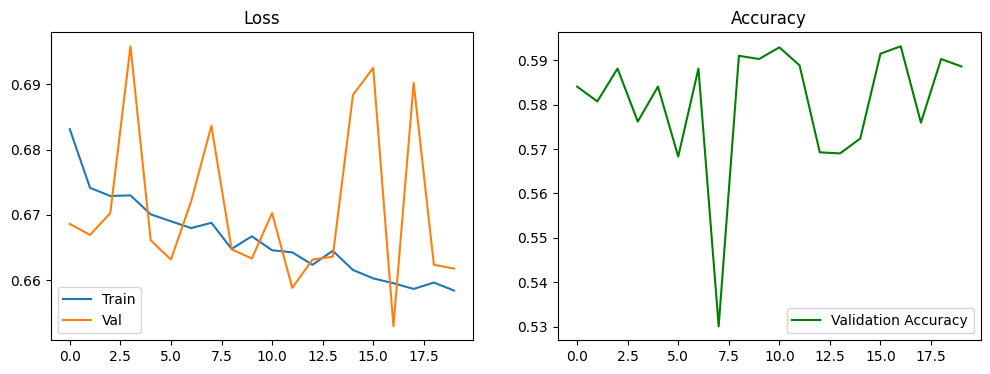

In [26]:
if len(all_files) > 0:
    print(f"🚀 Starting Training for {EPOCHS} epochs on {DEVICE}...")
    
    for epoch in range(EPOCHS):
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        
        # Progress bar for Training
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
        
        for inputs, labels in train_loop:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            train_loop.set_postfix(loss=loss.item())
            
        # --- VALIDATE ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        # Progress bar for Validation
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        
        with torch.no_grad():
            for inputs, labels in val_loop:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                predicted = (outputs > 0.5).float()
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        
        # Stats
        epoch_loss = running_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)
        epoch_acc = correct / total
        
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_acc)
        
        print(f"✅ Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_acc:.4f}")
        
        # Save Best
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"   --> 💾 Best model saved! (New Low: {best_val_loss:.4f})")

    # Plot History
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Validation Accuracy', color='green')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

else:
    print("❌ No data found.")


🔍 Running Final Evaluation...


Final Eval: 100%|██████████| 17/17 [00:05<00:00,  3.18it/s]



🏆 CNN (ResNet18) RESULTS:
Accuracy: 0.5931
AUC Score: 0.6374

              precision    recall  f1-score   support

         0.0       0.57      0.43      0.49      1899
         1.0       0.61      0.73      0.66      2289

    accuracy                           0.59      4188
   macro avg       0.59      0.58      0.58      4188
weighted avg       0.59      0.59      0.58      4188



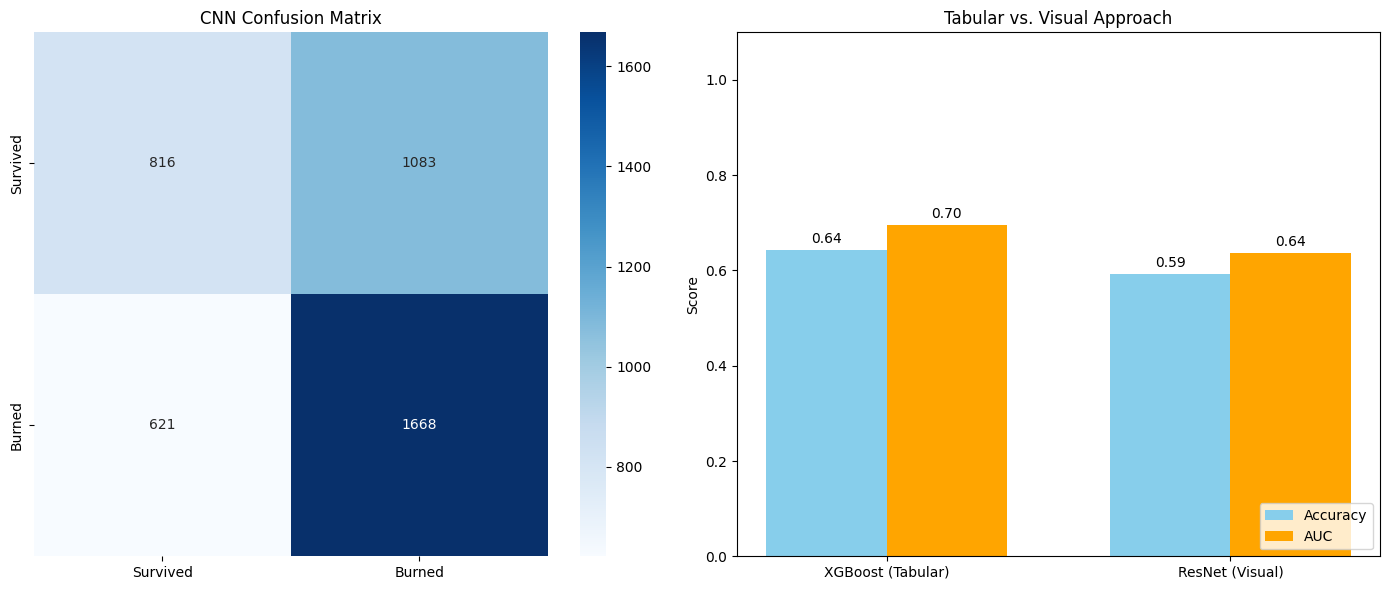

In [27]:
if len(all_files) > 0:
    print("\n🔍 Running Final Evaluation...")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()

    y_true = []
    y_pred_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Final Eval"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred_probs.extend(outputs.cpu().numpy())

    y_true = np.array(y_true).flatten()
    y_pred_probs = np.array(y_pred_probs).flatten()
    y_pred_cls = (y_pred_probs > 0.5).astype(int)

    cnn_acc = accuracy_score(y_true, y_pred_cls)
    cnn_auc = roc_auc_score(y_true, y_pred_probs)

    print(f"\n🏆 CNN (ResNet18) RESULTS:")
    print(f"Accuracy: {cnn_acc:.4f}")
    print(f"AUC Score: {cnn_auc:.4f}")
    print("\n" + classification_report(y_true, y_pred_cls))

    # --- VISUAL COMPARISON ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_cls)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Survived', 'Burned'], 
                yticklabels=['Survived', 'Burned'], ax=axes[0])
    axes[0].set_title("CNN Confusion Matrix")

    # Bar Chart
    models_list = ['XGBoost (Tabular)', 'ResNet (Visual)']
    accuracies = [xgb_acc, cnn_acc]
    aucs = [xgb_auc, cnn_auc]
    x = np.arange(len(models_list))
    width = 0.35

    rects1 = axes[1].bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
    rects2 = axes[1].bar(x + width/2, aucs, width, label='AUC', color='orange')

    axes[1].set_ylabel('Score')
    axes[1].set_title('Tabular vs. Visual Approach')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models_list)
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(loc='lower right')
    
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            axes[1].annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()